### Inference on a larger data set ###

In [1]:
import sys
import os
import numpy as np
import json
import pandas as pd
import logging
from pathlib import Path
from matplotlib import pyplot as plt
import albumentations as alb
import itertools

logger = logging.getLogger(__name__)

# PyTorch
import torch
from torch.utils.data import DataLoader
from torchvision import ops

# Hugging Face Library
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor

%load_ext autoreload
%autoreload 2
import computervision
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy
from computervision.imageproc import plot_boxes
from computervision.datasets import DETRdataset, get_gpu_info
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DetrInference

print(f'Project version: {computervision.__version__}')
print(f'Python version:  {sys.version}')

Project version: v0.0.2
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [2]:
# Check GPU availability
device, device_str = get_gpu_info()
print(f'Current device {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Device for model training/inference: cuda:0
Current device cuda:0


In [68]:
# Directories and files HSDM DATA 
dataset = 'dataset_object_240921'
annotations_file_name = 'objectdata_240921_clean_ide.parquet'
image_dir = os.path.join(os.environ.get('DATA'), dataset)
annotations_file = os.path.join(image_dir, annotations_file_name)

file_col = 'multi_file'
bbox_col = 'bbox'
pos_col = 'pos'

model_name = 'rtdetr_roboflow_251005_01'
model_dir = os.path.join(os.environ.get('DATA'), 'model', model_name)
checkpoint = 'checkpoint-3800'
checkpoint_dir = os.path.join(model_dir, checkpoint)

results_dir = os.path.join(model_dir, 'results')
Path(results_dir).mkdir(parents=True, exist_ok=True)

In [3]:
# Directories and files ROBOFLOW DATA
dataset = 'dataset_object_roboflow_240930'
annotations_file_name = 'roboflow_240930_dset.parquet'
image_dir = os.path.join(os.environ.get('DATA'), dataset)
annotations_file = os.path.join(image_dir, annotations_file_name)

file_col = 'multi_file'
bbox_col = 'bbox'
pos_col = 'pos'

model_name = 'rtdetr_roboflow_251005_01'
model_dir = os.path.join(os.environ.get('DATA'), 'model', model_name)
checkpoint = 'checkpoint-3800'
checkpoint_dir = os.path.join(model_dir, checkpoint)

results_dir = os.path.join(model_dir, 'results')
Path(results_dir).mkdir(parents=True, exist_ok=True)

In [4]:
# Load the model configuration files
config_file = os.path.join(model_dir, f'{model_name}.json')
with open(config_file, mode='r') as fl:
    model_config = json.load(fl)
display(sorted(list(model_config.keys())))

# Annotations for the test set
df = pd.read_parquet(annotations_file).astype({'pos': int})
# df = df.loc[df['dset'].isin(['val', 'test'])].reset_index(drop=True)

# Labels
# The PyTorch dataset needs a label column
id2label = model_config.get('id2label')
id2label = {int(k): int(v) for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}
df = df.assign(label=df[pos_col].apply(lambda pos: label2id.get(pos)))

# Image id
file_list = list(df[file_col].unique())
file2id = dict(zip(file_list, range(len(file_list))))
id2file = {v: k for k, v in file2id.items()}
df = df.assign(image_id=df[file_col].apply(lambda file: file2id.get(file)))
display(df.head(2))

['bbox_format', 'id2label', 'model_info', 'processor_params', 'training_args']

,id,license,file_name,height,width,date_captured,file_name_hash,dset,multi_file,bbox,category,disease,pos,box_id,label,image_id
1,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[8.0, 0.0, 130.293, 176.736]",tooth 23,teeth,11,40762886f4_1,10,0
2,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[130.0, 0.0, 258.408, 186.778]",tooth 25,teeth,13,40762886f4_2,12,0


### Create the dataset ###

In [6]:
batch_size = 4
detr = DetrInference(device=device, checkpoint_path=checkpoint_dir, batch_size=batch_size)
processor = detr.processor

data_select = df.loc[df[file_col].isin(file_list[:100])]

dataset = DETRdataset(data=data_select,
                      image_processor=processor,
                      image_dir=image_dir,
                      file_name_col=file_col,
                      label_id_col=None,
                      bbox_col=None,
                      transforms=[alb.NoOp()])



# Calculate the number of batches in the data set
n_images = len(dataset)
n_batches = int(np.floor(n_images / batch_size))
rest = int(n_images - (n_batches * batch_size))
if rest > 0:
    n_batches += 1
print(f'Number of images in data set:  {n_images}')
print(f'Batch size:                    {batch_size}')
print(f'Number of batches in data set: {n_batches}')

Number of images in data set:  100
Batch size:                    4
Number of batches in data set: 25


### Predict on the data set ###

In [7]:
# Add the correct position label
threshold = 0.05
pred_df = detr.predict_on_dataset(dataset=dataset, threshold=threshold)
pred_df = pred_df.assign(pos=pred_df['category_id'].apply(lambda cat: id2label.get(cat)))
pred_df = pred_df.assign(file=pred_df['image_id'].apply(lambda idx: id2file.get(idx)))
display(pred_df.head())

Predicting batch 10 of 25.
Predicting batch 20 of 25.


,image_id,image_width,image_height,batch,category_id,bbox,score,area,pos,file
0,0,640,480,0,18,"[323, 169, 316, 190]",0.981029,60040,19,40762886f4.jpg
1,0,640,480,0,17,"[508, 145, 131, 214]",0.975245,28034,18,40762886f4.jpg
2,0,640,480,0,19,"[206, 166, 337, 193]",0.971591,65041,20,40762886f4.jpg
3,0,640,480,0,21,"[3, 155, 79, 204]",0.08531,16116,22,40762886f4.jpg
4,0,640,480,0,14,"[437, 0, 202, 140]",0.06992,28280,15,40762886f4.jpg


40762886f4.jpg


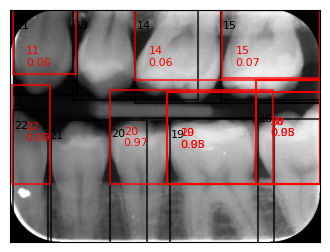

7f4dec7cde.jpg


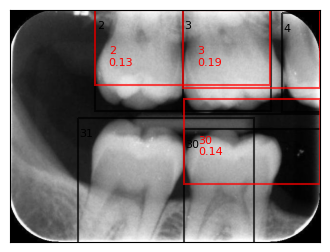

eb79ef10bf.jpg


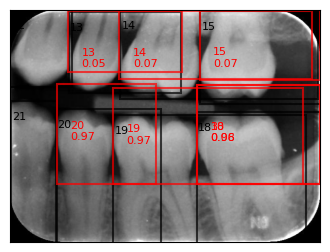

e1983a944c.jpg


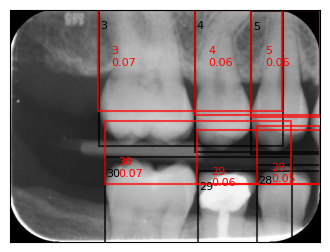

18df206516.jpg


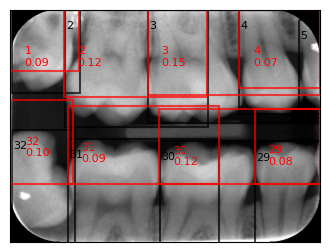

40feb6071f.jpg


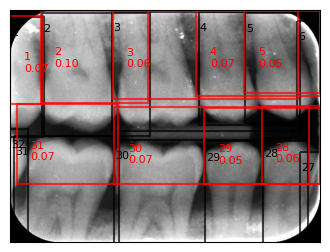

4c29b91f53.jpg


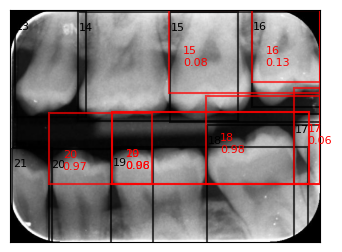

1aa6949ca1.jpg


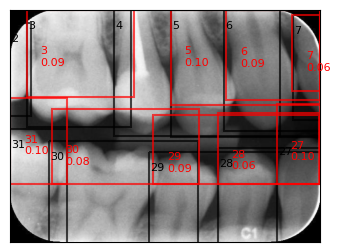

a3a1e7e508.jpg


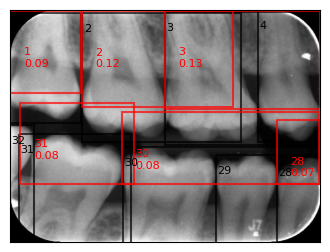

1ef42bf772.jpg


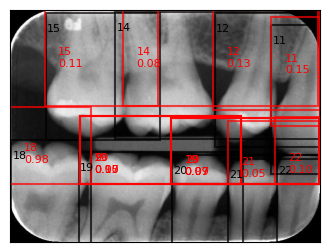

26306a4fb9.jpg


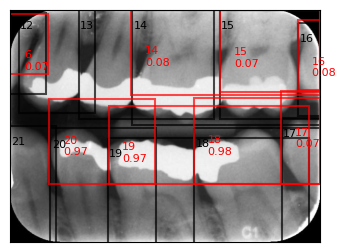

fb32344b01.jpg


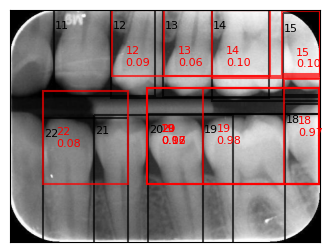

2e0906a919.jpg


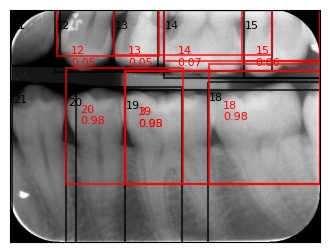

ddd5d3c9b9.jpg


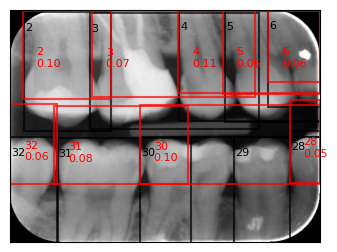

fe3e2169ac.jpg


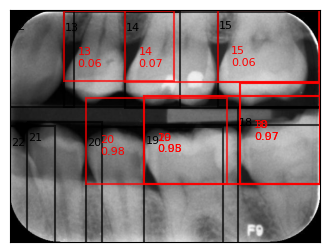

5a3b8ddbe4.jpg


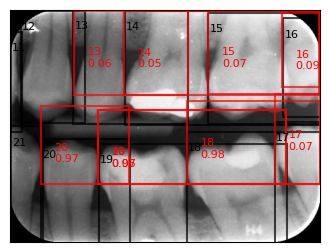

a010f849a7.jpg


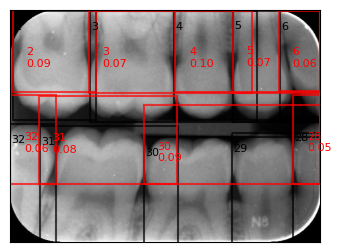

869f664fea.jpg


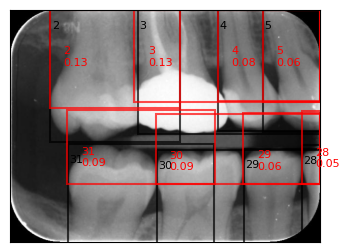

871524b9d9.jpg


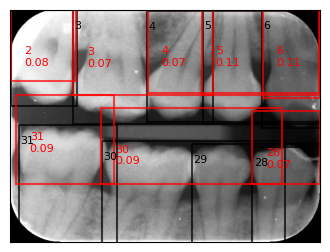

0c1be28f02.jpg


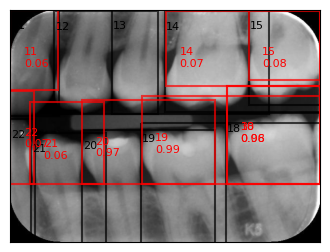

431ba7d386.jpg


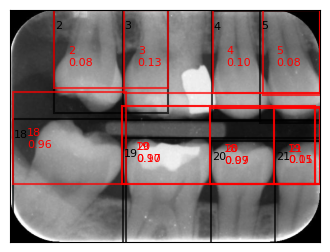

db22926932.jpg


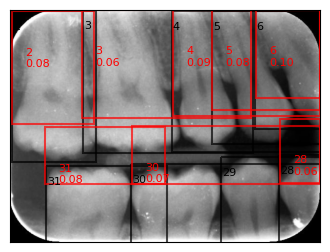

2254afa762.jpg


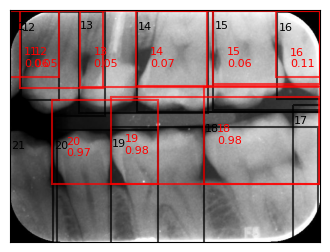

c9f2392fb3.jpg


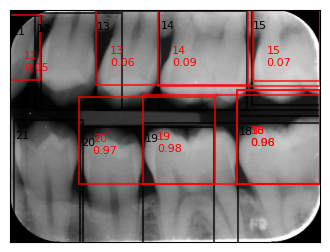

b4f6d695a2.jpg


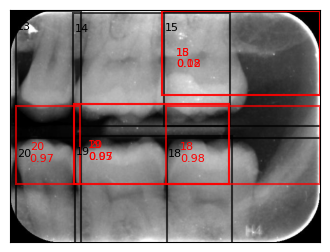

a671cc57fb.jpg


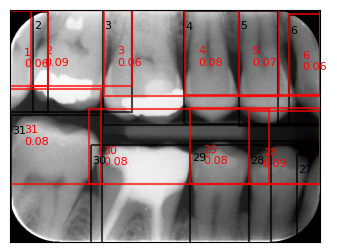

294a9f58ba.jpg


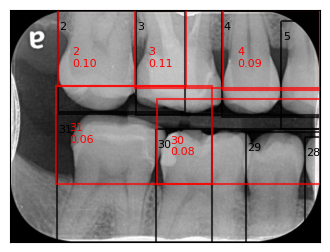

868148f76d.jpg


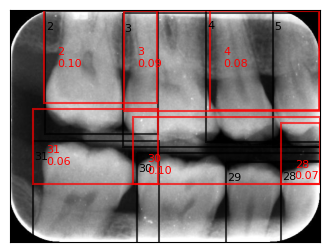

738ae24eb2.jpg


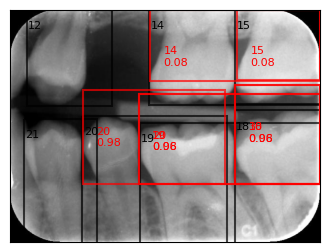

4b68fbc82f.jpg


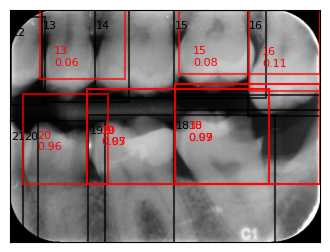

ce1d8326f8.jpg


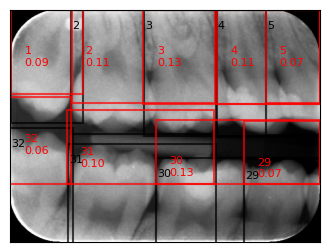

d347fa606f.jpg


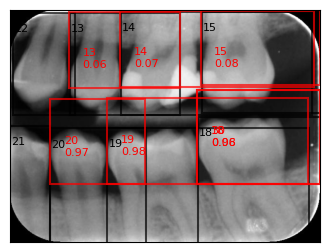

78d1018867.jpg


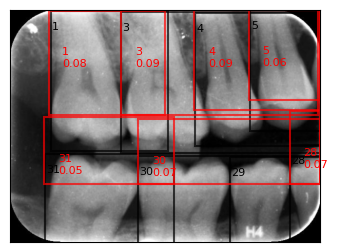

211d83d7b1.jpg


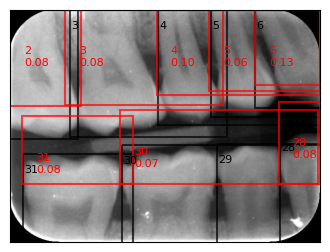

df7966d3f9.jpg


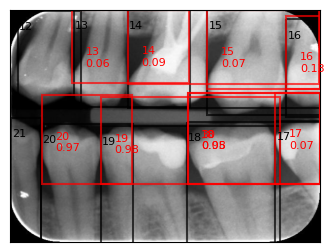

8f6469e5a9.jpg


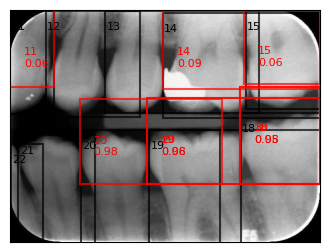

5d9a34e704.jpg


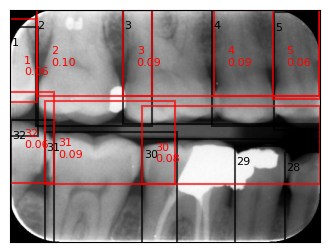

82367a2bb3.jpg


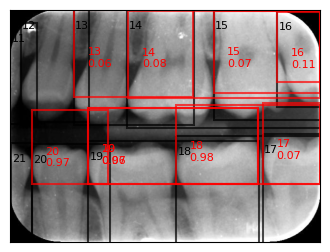

a5d59d7329.jpg


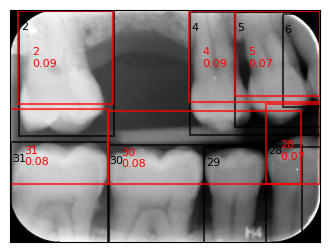

28de69ed83.jpg


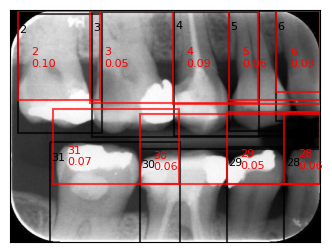

920796286c.jpg


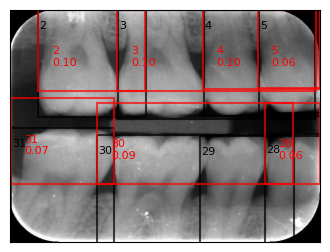

a0ab0bec5c.jpg


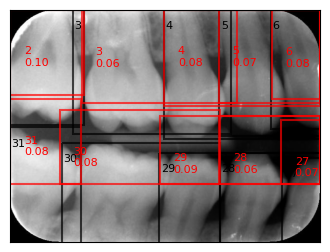

99a13b6851.jpg


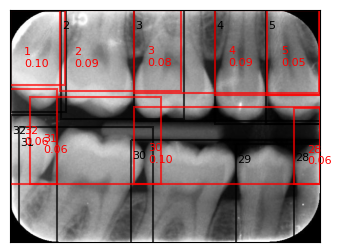

e2f716a37d.jpg


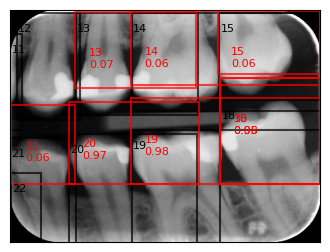

d2285fe196.jpg


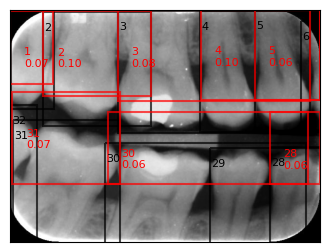

02b70cd555.jpg


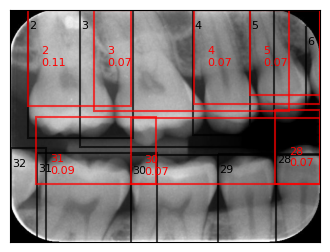

b66279b268.jpg


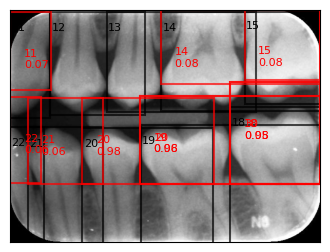

507da686ca.jpg


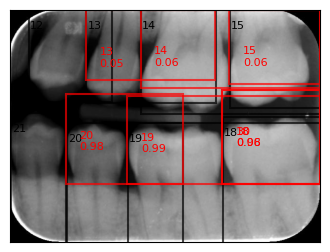

09a2e7743e.jpg


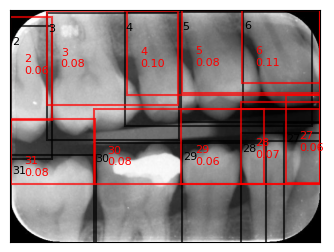

7c013bad28.jpg


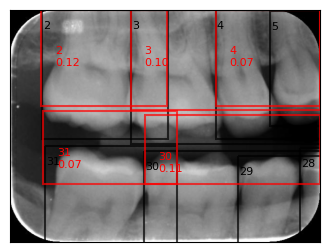

In [8]:
# Show some results
for file_name in file_list[:50]:

    print(file_name)
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im = ImageData().np2color(im)
    true_df = df.loc[df[file_col] == file_name]
    true_labels = true_df[pos_col].tolist()
    true_bboxes = true_df[bbox_col].tolist()
    
    model_df = pred_df.loc[pred_df['file'] == file_name]
    pred_pos = model_df['pos'].tolist()
    pred_scores = model_df['score'].tolist()
    pred_bboxes = model_df['bbox'].tolist()
    pred_labels = [f'{pos}\n{score:.2f}' for pos, score in zip(pred_pos, pred_scores)]
    
    fig, ax = plt.subplots(figsize=(4, 4))
    ax = plot_boxes(image=im, box_list=true_bboxes, label_list=true_labels, ax=ax, color='k')
    ax = plot_boxes(image=im, box_list=pred_bboxes, label_list=pred_labels, ax=ax, color='r', offset_xy=(100, 200))
    plt.show()